# EDA — Dataset SIEM Wazuh INSTIKI

### Analisis Komprehensif untuk Skripsi: Reduksi Alert Fatigue dengan RBTA

**Tujuan notebook ini:**

- Memahami distribusi, pola, dan karakteristik data alert Wazuh secara menyeluruh
- Mengidentifikasi potensi masalah data sebelum masuk ke pipeline RBTA
- Memberikan insight untuk justifikasi metodologi di Bab 3 dan pembahasan Bab 4

**Dataset:** `rbta_ready_all_sample.csv`  
**Ganti path di cell pertama sesuai lokasi file kamu.**


In [4]:
# ── SETUP ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Ganti path ini sesuai lokasi file CSV kamu ────────────────────────────
CSV_PATH = '../data/rbta_ready_all.csv'

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F9',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'font.size':        10,
})

C_PRIMARY = '#534AB7'
C_ACCENT  = '#1D9E75'
C_WARN    = '#BA7517'
C_RED     = '#C94040'
C_GRAY    = '#888780'

AGENT_PALETTE = {
    'sads':          '#534AB7',
    'pusatkarir':    '#1D9E75',
    'siput':         '#BA7517',
    'e-kuesioner':   '#C94040',
    'dfir-iris':     '#378ADD',
    'proxy-manager': '#D85A30',
    'DVWA':          '#639922',
    'soc-1':         '#888780',
}

print('Libraries loaded. Reading dataset...')

Libraries loaded. Reading dataset...


---

## 1. LOAD & OVERVIEW DASAR


In [5]:
# ── Load data ─────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, low_memory=False)

# Parse timestamp
df['timestamp'] = pd.to_datetime(df['timestamp_utc'], format='ISO8601', utc=True)
df['timestamp_local'] = df['timestamp'].dt.tz_convert('Asia/Makassar')  # WIB+1 = WITA
df['date']        = df['timestamp_local'].dt.date
df['hour']        = df['timestamp_local'].dt.hour
df['day_of_week'] = df['timestamp_local'].dt.dayofweek   # 0=Senin
df['month']       = df['timestamp_local'].dt.to_period('M')
df['week']        = df['timestamp_local'].dt.to_period('W')

print('=' * 60)
print(f'  RINGKASAN DATASET')
print('=' * 60)
print(f'  Total raw alerts      : {len(df):,}')
print(f'  Jumlah kolom          : {df.shape[1]}')
print(f'  Tanggal pertama (WITA): {df["timestamp_local"].min().strftime("%Y-%m-%d %H:%M")}')
print(f'  Tanggal terakhir (WITA): {df["timestamp_local"].max().strftime("%Y-%m-%d %H:%M")}')
print(f'  Rentang waktu         : {df["date"].max() - df["date"].min()} hari')
print(f'  Hari unik berdata     : {df["date"].nunique()}')
print(f'  Agent unik            : {df["agent_name"].nunique()}')
print(f'  Rule group unik       : {df["rule_group_primary"].nunique()}')
print(f'  Rule ID unik          : {df["rule_id"].nunique()}')
print('=' * 60)

  RINGKASAN DATASET
  Total raw alerts      : 1,430,776
  Jumlah kolom          : 36
  Tanggal pertama (WITA): 2025-05-10 10:06
  Tanggal terakhir (WITA): 2026-04-02 07:59
  Rentang waktu         : 327 days, 0:00:00 hari
  Hari unik berdata     : 321
  Agent unik            : 8
  Rule group unik       : 22
  Rule ID unik          : 114


In [6]:
# ── Missing values analysis ────────────────────────────────────────────────
print('MISSING VALUES PER KOLOM:')
null_summary = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Pct (%)': (df.isnull().sum() / len(df) * 100).round(1),
    'Dtype':   df.dtypes.astype(str)
}).query('Missing > 0').sort_values('Pct (%)', ascending=False)

display(null_summary.style
    .background_gradient(subset=['Pct (%)'], cmap='Reds')
    .format({'Missing': '{:,}', 'Pct (%)': '{:.1f}%'})
    .set_caption('Kolom dengan missing values'))

MISSING VALUES PER KOLOM:


,Missing,Pct (%),Dtype
audit_command,"1,416,260",99.0%,object
syscheck_path,"1,320,682",92.3%,object
syscheck_mode,"1,320,682",92.3%,object
syscheck_event,"1,320,682",92.3%,object
mitre_technique,"1,290,391",90.2%,object
mitre_tactic,"1,290,391",90.2%,object
mitre_id,"1,290,391",90.2%,object
data_url,"422,523",29.5%,object
srcip,"389,441",27.2%,object
full_log,"61,346",4.3%,object


In [7]:
# ── Tipe data dan contoh nilai ─────────────────────────────────────────────
print('TIPE DATA & CONTOH NILAI:')
sample_vals = {}
for col in df.columns:
    vals = df[col].dropna().unique()
    n_unique = len(vals)
    examples = ', '.join([str(v)[:30] for v in vals[:3]])
    sample_vals[col] = {'dtype': str(df[col].dtype), 'n_unique': n_unique, 'examples': examples}

display(pd.DataFrame(sample_vals).T.style
    .set_caption('Ringkasan tipe data'))

TIPE DATA & CONTOH NILAI:


,dtype,n_unique,examples
wazuh_alert_id,float64,1430776,"1746842806.0, 1746842810.241, 1746842810.3869"
timestamp_utc,object,1173936,"2025-05-10 02:06:46.854000+00:, 2025-05-10 02:06:50.651000+00:, 2025-05-10 02:06:50.679000+00:"
agent_id,int64,8,"0, 1, 2"
agent_name,object,8,"soc-1, pusatkarir, dfir-iris"
rule_group_primary,object,22,"ossec, sca, syslog"
rule_level,int64,12,"3, 7, 8"
rule_id,int64,114,"502, 19007, 19008"
srcip,object,263,"172.16.200.116, 10.101.107.183, 172.16.81.86"
srcip_type,object,3,"none, internal, external"
criticality_score,int64,4,"1, 3, 4"


---

## 2. ANALISIS TEMPORAL (WAKTU)


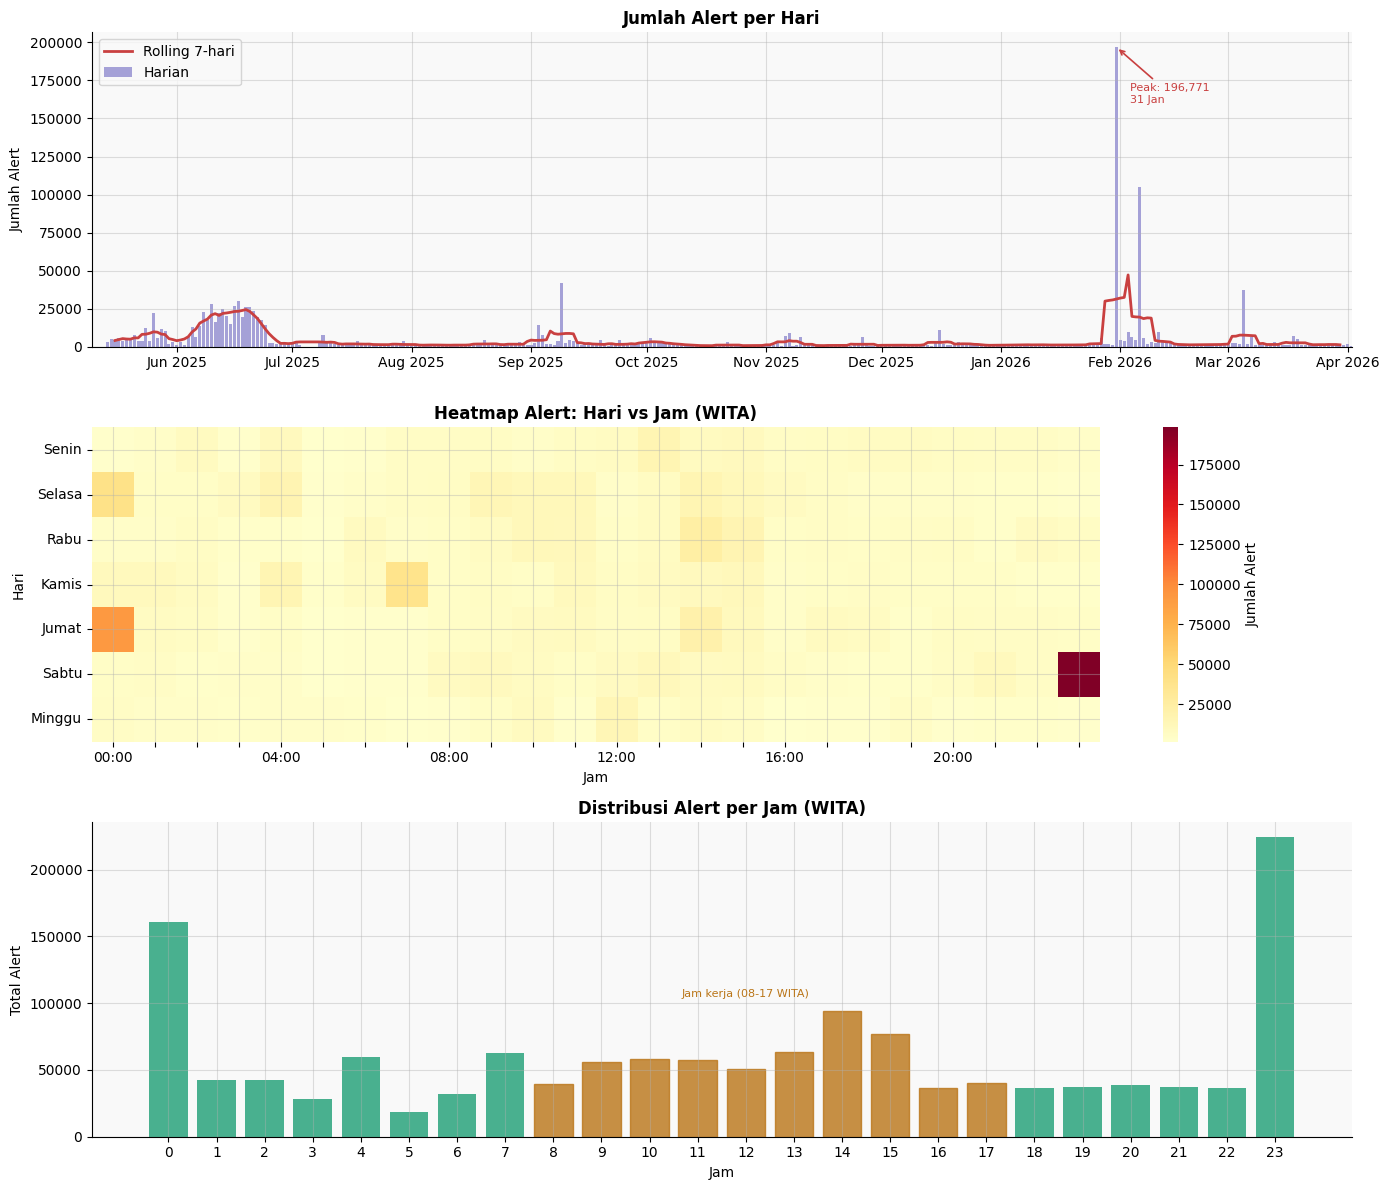

Insight: Alert terbanyak jam 23:00 WITA (224,281 total)
Insight: Hari terbanyak: Sabtu (335,531 alert)


In [8]:
# ── Alert per hari ─────────────────────────────────────────────────────────
daily = df.groupby('date').size().reset_index(name='count')
daily['date'] = pd.to_datetime(daily['date'])
daily['rolling7'] = daily['count'].rolling(7, center=True).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Daily volume
ax = axes[0]
ax.bar(daily['date'], daily['count'], color=C_PRIMARY, alpha=0.5, width=0.8, label='Harian')
ax.plot(daily['date'], daily['rolling7'], color=C_RED, linewidth=2, label='Rolling 7-hari')
ax.set_title('Jumlah Alert per Hari', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Alert')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend()
ax.set_xlim(daily['date'].min(), daily['date'].max())
# Anotasi peak
peak_day = daily.loc[daily['count'].idxmax()]
ax.annotate(f'Peak: {int(peak_day["count"]):,}\n{peak_day["date"].strftime("%d %b")}',
            xy=(peak_day['date'], peak_day['count']),
            xytext=(10, -40), textcoords='offset points',
            fontsize=8, color=C_RED,
            arrowprops=dict(arrowstyle='->', color=C_RED, lw=1.2))

# Plot 2: Alert per jam (heatmap)
ax = axes[1]
hourly = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
days_label = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
sns.heatmap(hourly, ax=ax, cmap='YlOrRd', linewidths=0,
            xticklabels=[f'{h:02d}:00' if h % 4 == 0 else '' for h in range(24)],
            yticklabels=days_label,
            cbar_kws={'label': 'Jumlah Alert'})
ax.set_title('Heatmap Alert: Hari vs Jam (WITA)', fontsize=12, fontweight='bold')
ax.set_xlabel('Jam')
ax.set_ylabel('Hari')

# Plot 3: Distribusi jam
ax = axes[2]
hourly_total = df.groupby('hour').size()
bars = ax.bar(hourly_total.index, hourly_total.values, color=C_ACCENT, alpha=0.8)
ax.set_title('Distribusi Alert per Jam (WITA)', fontsize=12, fontweight='bold')
ax.set_xlabel('Jam')
ax.set_ylabel('Total Alert')
ax.set_xticks(range(0, 24))
# Warnai jam kerja vs non-kerja
for bar, h in zip(bars, hourly_total.index):
    if 8 <= h <= 17:
        bar.set_color(C_WARN)
ax.annotate('Jam kerja (08-17 WITA)', xy=(12, hourly_total[8:18].max()),
            fontsize=8, color=C_WARN, ha='center',
            xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Insight: Alert terbanyak jam {hourly_total.idxmax()}:00 WITA ({hourly_total.max():,} total)")
print(f"Insight: Hari terbanyak: {days_label[hourly.sum(axis=1).idxmax()]} ({hourly.sum(axis=1).max():,} alert)")

In [9]:
# ── Gap analysis: apakah ada periode tanpa data? ──────────────────────────
all_dates = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
existing = pd.to_datetime(df['date'].unique())
missing_dates = [d for d in all_dates if d not in set(existing)]

print(f'Total hari dalam rentang: {len(all_dates)}')
print(f'Hari berdata             : {len(existing)}')
print(f'Hari tanpa data (gap)    : {len(missing_dates)}')
if missing_dates:
    print('\nTanggal tanpa data:')
    for d in missing_dates[:20]:
        print(f'  {d.strftime("%Y-%m-%d")}')
    if len(missing_dates) > 20:
        print(f'  ... dan {len(missing_dates)-20} hari lainnya')
else:
    print('Tidak ada gap temporal.')

# Statistik harian
print(f'\nStatistik jumlah alert per hari:')
print(daily['count'].describe().round(1).to_string())
print(f'Hari paling sepi  : {daily.loc[daily["count"].idxmin(), "date"].strftime("%Y-%m-%d")} ({daily["count"].min()} alert)')
print(f'Hari paling ramai : {daily.loc[daily["count"].idxmax(), "date"].strftime("%Y-%m-%d")} ({daily["count"].max():,} alert)')

Total hari dalam rentang: 328
Hari berdata             : 321
Hari tanpa data (gap)    : 7

Tanggal tanpa data:
  2025-05-11
  2025-05-12
  2025-05-13
  2025-07-04
  2025-07-05
  2025-07-06
  2025-07-07

Statistik jumlah alert per hari:
count       321.0
mean       4457.2
std       13508.9
min         312.0
25%        1036.0
50%        1377.0
75%        3122.0
max      196771.0
Hari paling sepi  : 2026-04-02 (312 alert)
Hari paling ramai : 2026-01-31 (196,771 alert)


In [ ]:
# ── Inter-arrival time (IAT): waktu antar alert ───────────────────────────
df_sorted = df.sort_values('timestamp')
iat = df_sorted['timestamp'].diff().dt.total_seconds().dropna()
iat = iat[iat > 0]  # buang negatif/nol

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi IAT
ax = axes[0]
ax.hist(iat[iat < 60], bins=60, color=C_PRIMARY, alpha=0.75, edgecolor='white', linewidth=0.3)
ax.set_title('Distribusi Inter-Arrival Time (IAT) ≤ 60 detik', fontsize=11, fontweight='bold')
ax.set_xlabel('Detik antar alert')
ax.set_ylabel('Frekuensi')
pct_burst = (iat < 1).sum() / len(iat) * 100
ax.axvline(1, color=C_RED, linestyle='--', label=f'< 1 detik: {pct_burst:.1f}% dari IAT')
ax.legend(fontsize=9)

# Log-scale IAT
ax = axes[1]
ax.hist(iat, bins=np.logspace(np.log10(0.001), np.log10(iat.max()), 60),
        color=C_ACCENT, alpha=0.75, edgecolor='white', linewidth=0.3)
ax.set_xscale('log')
ax.set_title('IAT Distribution (log scale) — Seluruh Range', fontsize=11, fontweight='bold')
ax.set_xlabel('Detik antar alert (log)')
ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_iat.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'IAT Statistics:')
print(f'  Median IAT        : {iat.median():.3f} detik')
print(f'  Mean IAT          : {iat.mean():.3f} detik')
print(f'  IAT < 1 detik     : {pct_burst:.1f}% ("burst" alerts)')
print(f'  IAT < 5 detik     : {(iat<5).mean()*100:.1f}%')
print(f'  IAT < 15 menit    : {(iat<900).mean()*100:.1f}%')
print(f'\nINSIGHT untuk RBTA:')
print(f'  Δt=1 menit akan menangkap {(iat<60).mean()*100:.1f}% pasangan alert berurutan')
print(f'  Δt=5 menit akan menangkap {(iat<300).mean()*100:.1f}% pasangan alert berurutan')
print(f'  Δt=15 menit akan menangkap {(iat<900).mean()*100:.1f}% pasangan alert berurutan')

---

## 3. ANALISIS AGENT (SERVER)


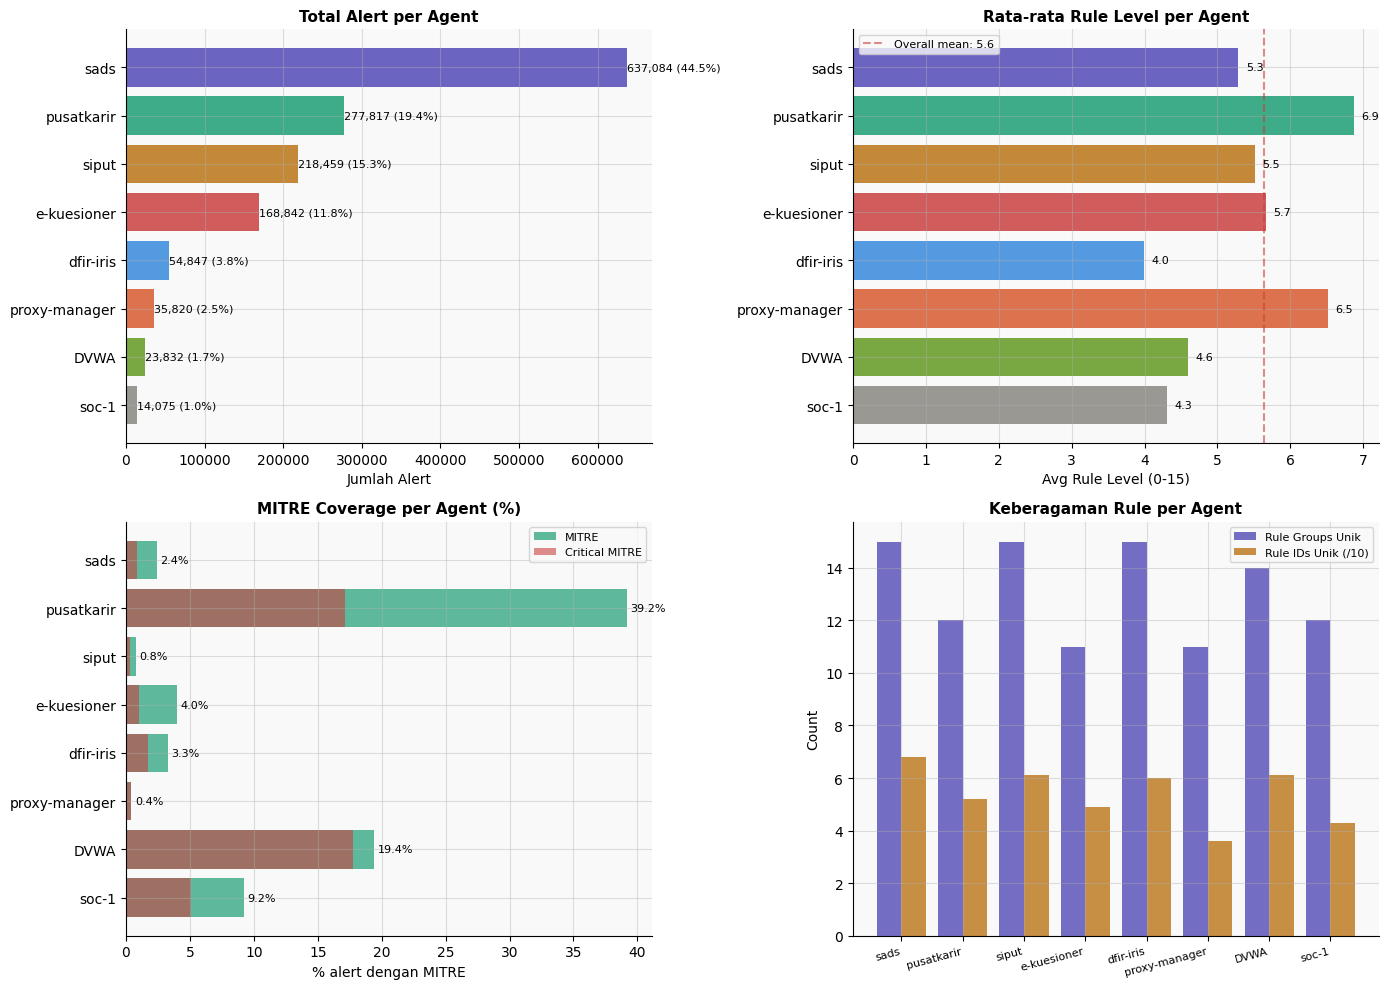


SUMMARY TABLE AGENT:


,Total Alert,% Total,Avg Level,Max Level,MITRE %,Crit. MITRE %,Rule Groups,Crit Score,Criticality
agent_name,,,,,,,,,
sads,637084,44.5%,5.29,12,2.4%,0.9%,15,3,high
pusatkarir,277817,19.4%,6.87,15,39.2%,17.1%,12,3,high
siput,218459,15.3%,5.52,12,0.8%,0.3%,15,2,medium
e-kuesioner,168842,11.8%,5.67,12,4.0%,1.0%,11,2,medium
dfir-iris,54847,3.8%,3.99,15,3.3%,1.7%,15,4,critical
proxy-manager,35820,2.5%,6.51,11,0.4%,0.4%,11,3,high
DVWA,23832,1.7%,4.60,15,19.4%,17.8%,14,1,low
soc-1,14075,1.0%,4.30,12,9.2%,5.1%,12,1,low


In [10]:
# ── Distribusi per agent ───────────────────────────────────────────────────
agent_stats = df.groupby('agent_name').agg(
    total=('rule_level', 'count'),
    avg_level=('rule_level', 'mean'),
    max_level=('rule_level', 'max'),
    mitre_rate=('has_mitre', 'mean'),
    critical_mitre_rate=('has_critical_mitre', 'mean'),
    n_rule_groups=('rule_group_primary', 'nunique'),
    n_rule_ids=('rule_id', 'nunique'),
    criticality=('criticality_score', 'first'),
    agent_crit_label=('agent_criticality', 'first'),
).sort_values('total', ascending=False)

agent_stats['pct'] = agent_stats['total'] / agent_stats['total'].sum() * 100
agent_stats['mitre_pct'] = agent_stats['mitre_rate'] * 100
agent_stats['critical_mitre_pct'] = agent_stats['critical_mitre_rate'] * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total alerts
ax = axes[0, 0]
colors = [AGENT_PALETTE.get(a, '#888780') for a in agent_stats.index]
bars = ax.barh(agent_stats.index[::-1], agent_stats['total'][::-1], color=colors[::-1], alpha=0.85)
ax.set_title('Total Alert per Agent', fontsize=11, fontweight='bold')
ax.set_xlabel('Jumlah Alert')
for bar, val, pct in zip(bars, agent_stats['total'][::-1], agent_stats['pct'][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=8)

# Plot 2: Avg rule level
ax = axes[0, 1]
colors2 = [AGENT_PALETTE.get(a, '#888780') for a in agent_stats.index]
bars2 = ax.barh(agent_stats.index[::-1], agent_stats['avg_level'][::-1], color=colors2[::-1], alpha=0.85)
ax.set_title('Rata-rata Rule Level per Agent', fontsize=11, fontweight='bold')
ax.set_xlabel('Avg Rule Level (0-15)')
ax.axvline(df['rule_level'].mean(), color=C_RED, linestyle='--', alpha=0.6,
           label=f'Overall mean: {df["rule_level"].mean():.1f}')
ax.legend(fontsize=8)
for bar, val in zip(bars2, agent_stats['avg_level'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8)

# Plot 3: MITRE hit rate
ax = axes[1, 0]
bars3 = ax.barh(agent_stats.index[::-1], agent_stats['mitre_pct'][::-1], color=C_ACCENT, alpha=0.7, label='MITRE')
ax.barh(agent_stats.index[::-1], agent_stats['critical_mitre_pct'][::-1], color=C_RED, alpha=0.6, label='Critical MITRE')
ax.set_title('MITRE Coverage per Agent (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('% alert dengan MITRE')
ax.legend(fontsize=8)
for bar, val in zip(bars3, agent_stats['mitre_pct'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

# Plot 4: Rule diversity
ax = axes[1, 1]
x = np.arange(len(agent_stats))
w = 0.4
ax.bar(x - w/2, agent_stats['n_rule_groups'], w, color=C_PRIMARY, alpha=0.8, label='Rule Groups Unik')
ax.bar(x + w/2, agent_stats['n_rule_ids'] / 10, w, color=C_WARN, alpha=0.8, label='Rule IDs Unik (/10)')
ax.set_title('Keberagaman Rule per Agent', fontsize=11, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(agent_stats.index, rotation=15, ha='right', fontsize=8)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_agents.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSUMMARY TABLE AGENT:')
display(agent_stats[['total', 'pct', 'avg_level', 'max_level', 'mitre_pct', 
                       'critical_mitre_pct', 'n_rule_groups', 'criticality', 'agent_crit_label']]
    .rename(columns={
        'total': 'Total Alert', 'pct': '% Total', 'avg_level': 'Avg Level',
        'max_level': 'Max Level', 'mitre_pct': 'MITRE %', 'critical_mitre_pct': 'Crit. MITRE %',
        'n_rule_groups': 'Rule Groups', 'criticality': 'Crit Score', 'agent_crit_label': 'Criticality'
    })
    .style
    .background_gradient(subset=['% Total'], cmap='Blues')
    .background_gradient(subset=['MITRE %'], cmap='Greens')
    .format({'% Total': '{:.1f}%', 'Avg Level': '{:.2f}', 'MITRE %': '{:.1f}%', 'Crit. MITRE %': '{:.1f}%'}))

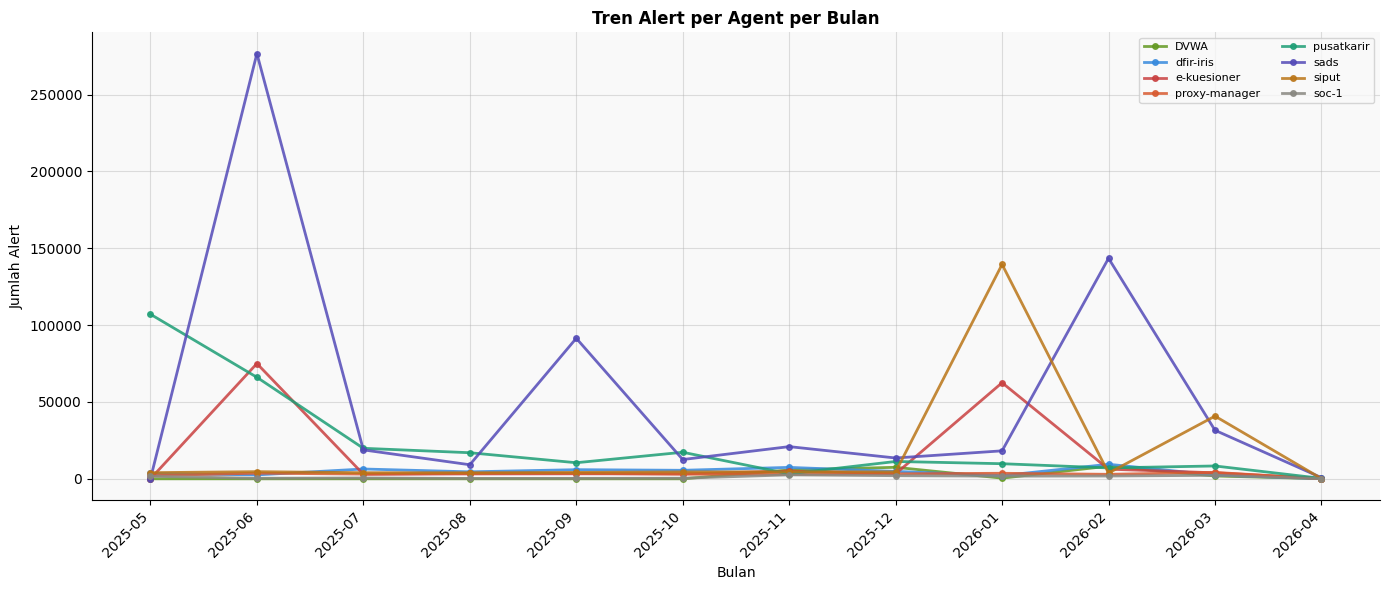

In [11]:
# ── Alert per agent per bulan (tren) ──────────────────────────────────────
monthly_agent = df.groupby(['month', 'agent_name']).size().unstack(fill_value=0)
monthly_agent.index = monthly_agent.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
for agent in monthly_agent.columns:
    color = AGENT_PALETTE.get(agent, '#888780')
    ax.plot(monthly_agent.index, monthly_agent[agent],
            marker='o', linewidth=2, markersize=4, label=agent, color=color, alpha=0.85)

ax.set_title('Tren Alert per Agent per Bulan', fontsize=12, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Alert')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_monthly_agent.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 4. ANALISIS RULE GROUP & RULE LEVEL


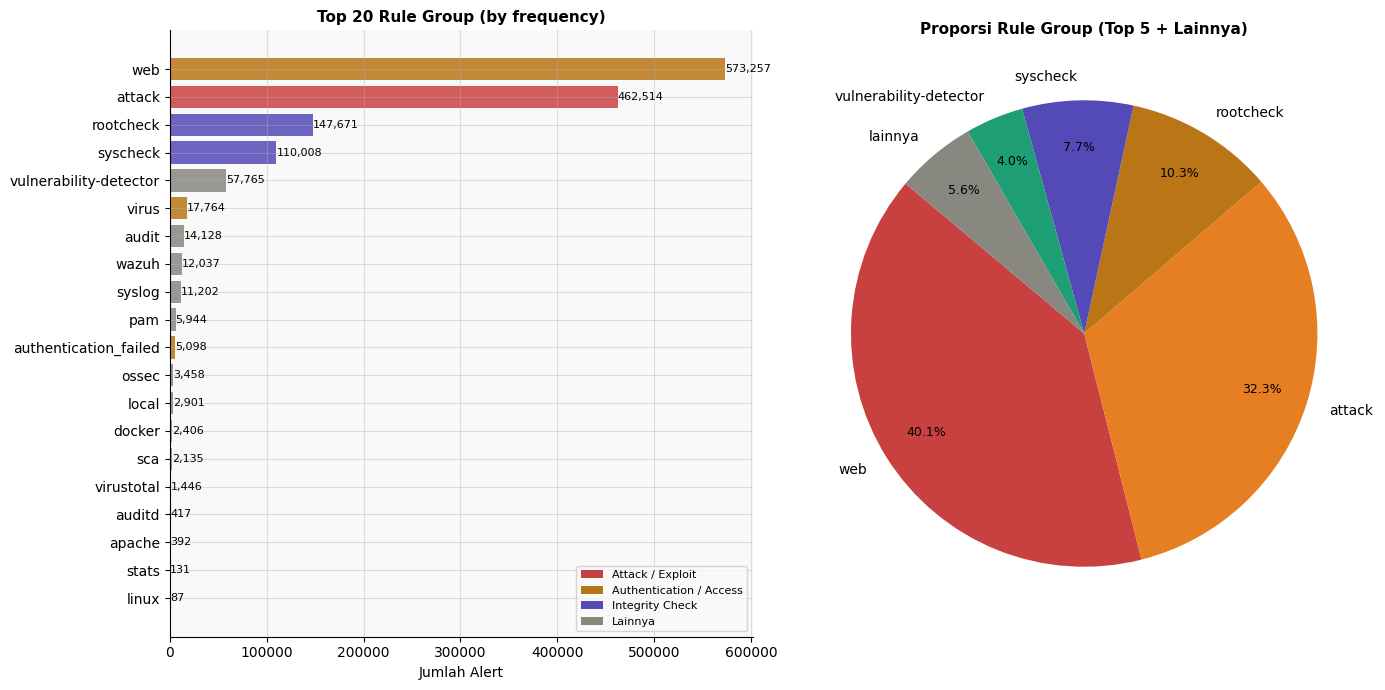


Total rule groups unik: 22
Top 5 groups = 94.4% dari semua alert


In [12]:
# ── Top rule groups ────────────────────────────────────────────────────────
rg_counts = df['rule_group_primary'].value_counts()
rg_top20 = rg_counts.head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Bar chart top 20
ax = axes[0]
colors_rg = [C_RED if rg in ['attack', 'sql_injection', 'webshell', 'judol_file']
             else C_WARN if rg in ['authentication_failed', 'access_control', 'web', 'virus']
             else C_PRIMARY if rg in ['rootcheck', 'syscheck', 'syscheck_file']
             else C_GRAY for rg in rg_top20.index]
bars = ax.barh(rg_top20.index[::-1], rg_top20.values[::-1], color=colors_rg[::-1], alpha=0.85)
ax.set_title('Top 20 Rule Group (by frequency)', fontsize=11, fontweight='bold')
ax.set_xlabel('Jumlah Alert')
for bar, val in zip(bars, rg_top20.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C_RED, label='Attack / Exploit'),
    Patch(facecolor=C_WARN, label='Authentication / Access'),
    Patch(facecolor=C_PRIMARY, label='Integrity Check'),
    Patch(facecolor=C_GRAY, label='Lainnya'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

# Pie chart proportions
ax = axes[1]
top5 = rg_counts.head(5)
others = rg_counts[5:].sum()
pie_data = list(top5.values) + [others]
pie_labels = list(top5.index) + ['lainnya']
pie_colors = [C_RED, '#E67E22', C_WARN, C_PRIMARY, C_ACCENT, C_GRAY]
wedges, texts, autotexts = ax.pie(
    pie_data, labels=pie_labels, autopct='%1.1f%%',
    colors=pie_colors, startangle=140, pctdistance=0.8)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Proporsi Rule Group (Top 5 + Lainnya)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_rule_groups.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal rule groups unik: {len(rg_counts)}')
print(f'Top 5 groups = {rg_counts.head(5).sum()/len(df)*100:.1f}% dari semua alert')

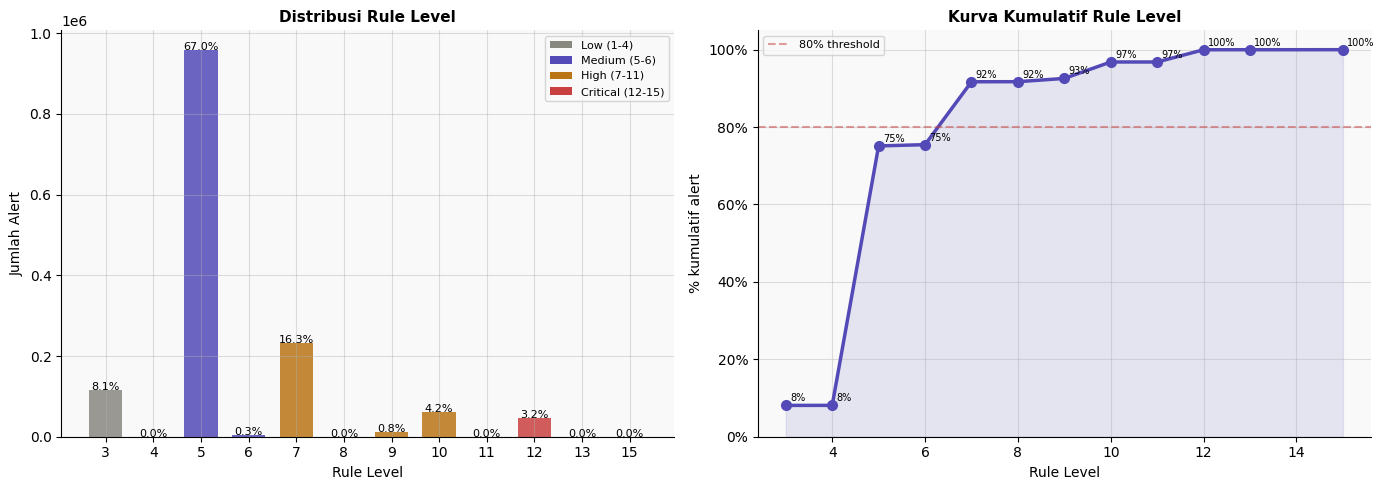

DISTRIBUSI SEVERITY ZONE:
  Low (1-4)           : 115,979 alerts (8.1%)
  Medium (5-6)        : 963,648 alerts (67.4%)
  High (7-11)         : 305,700 alerts (21.4%)
  Critical (12-15)    : 45,449 alerts (3.2%)

INSIGHT: Level 5 mendominasi (67.0%) — ini adalah SCA (Security Config Assessment) alerts yang repetitif dan ideal untuk agregasi RBTA


In [13]:
# ── Rule level distribution ────────────────────────────────────────────────
level_counts = df['rule_level'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar per level
ax = axes[0]
colors_level = []
for lv in level_counts.index:
    if lv >= 12: colors_level.append(C_RED)
    elif lv >= 7: colors_level.append(C_WARN)
    elif lv >= 5: colors_level.append(C_PRIMARY)
    else: colors_level.append(C_GRAY)
bars = ax.bar(level_counts.index.astype(str), level_counts.values,
              color=colors_level, alpha=0.85, width=0.7)
ax.set_title('Distribusi Rule Level', fontsize=11, fontweight='bold')
ax.set_xlabel('Rule Level')
ax.set_ylabel('Jumlah Alert')
for bar, val in zip(bars, level_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', fontsize=8)
# Legend severity zones
legend_elements = [
    Patch(facecolor=C_GRAY,    label='Low (1-4)'),
    Patch(facecolor=C_PRIMARY, label='Medium (5-6)'),
    Patch(facecolor=C_WARN,    label='High (7-11)'),
    Patch(facecolor=C_RED,     label='Critical (12-15)'),
]
ax.legend(handles=legend_elements, fontsize=8)

# Cumulative
ax = axes[1]
cumul = level_counts.cumsum() / level_counts.sum() * 100
ax.plot(cumul.index, cumul.values, marker='o', color=C_PRIMARY, linewidth=2.5, markersize=7)
ax.fill_between(cumul.index, cumul.values, alpha=0.12, color=C_PRIMARY)
ax.axhline(80, color=C_RED, linestyle='--', alpha=0.5, label='80% threshold')
ax.set_title('Kurva Kumulatif Rule Level', fontsize=11, fontweight='bold')
ax.set_xlabel('Rule Level')
ax.set_ylabel('% kumulatif alert')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=8)
for lv, val in cumul.items():
    ax.annotate(f'{val:.0f}%', xy=(lv, val), xytext=(3, 3),
                textcoords='offset points', fontsize=7)

plt.tight_layout()
plt.savefig('eda_rule_level.png', dpi=150, bbox_inches='tight')
plt.show()

# Severity zone summary
print('DISTRIBUSI SEVERITY ZONE:')
zones = {'Low (1-4)': df[df['rule_level'] <= 4],
         'Medium (5-6)': df[df['rule_level'].between(5, 6)],
         'High (7-11)': df[df['rule_level'].between(7, 11)],
         'Critical (12-15)': df[df['rule_level'] >= 12]}
for zone, subset in zones.items():
    print(f'  {zone:<20}: {len(subset):>6,} alerts ({len(subset)/len(df)*100:.1f}%)')

print(f'\nINSIGHT: Level 5 mendominasi ({level_counts.get(5,0)/len(df)*100:.1f}%) — '
      f'ini adalah SCA (Security Config Assessment) alerts yang repetitif dan ideal untuk agregasi RBTA')

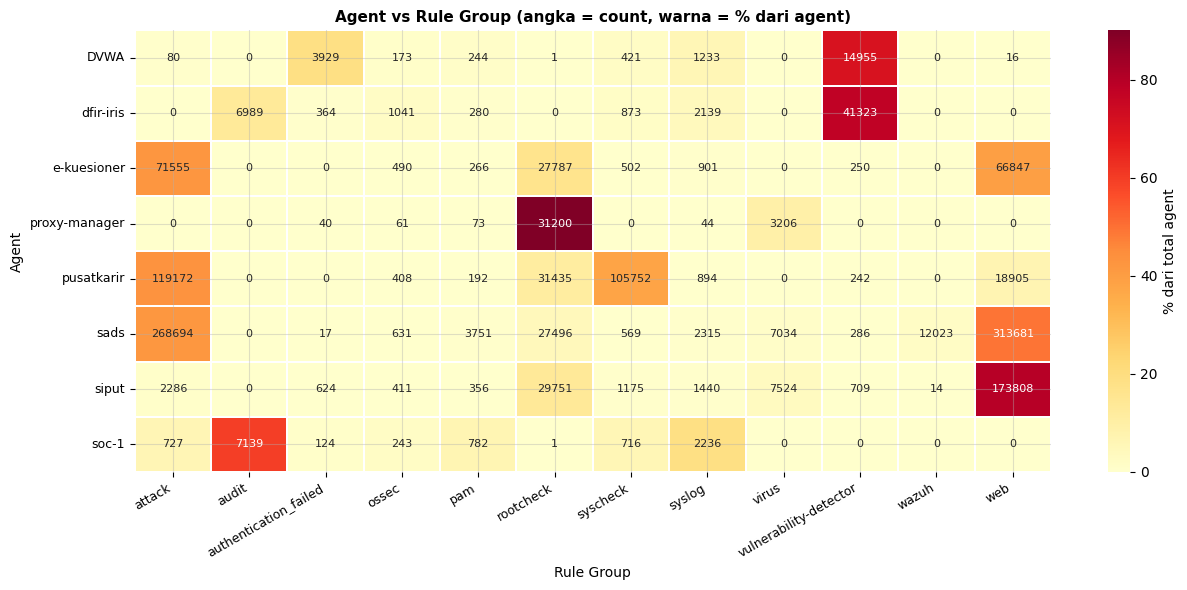

DOMINASI RULE GROUP PER AGENT:
  DVWA           : top group = vulnerability-detector    (71.0% alert agent ini)
  dfir-iris      : top group = vulnerability-detector    (78.0% alert agent ini)
  e-kuesioner    : top group = attack                    (42.4% alert agent ini)
  proxy-manager  : top group = rootcheck                 (90.1% alert agent ini)
  pusatkarir     : top group = attack                    (43.0% alert agent ini)
  sads           : top group = web                       (49.3% alert agent ini)
  siput          : top group = web                       (79.7% alert agent ini)
  soc-1          : top group = audit                     (59.7% alert agent ini)


In [14]:
# ── Rule group × Agent heatmap ────────────────────────────────────────────
top_groups = df['rule_group_primary'].value_counts().head(12).index
pivot = df[df['rule_group_primary'].isin(top_groups)]\
    .groupby(['agent_name', 'rule_group_primary']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
# Normalize per agent untuk lihat proporsi
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100
sns.heatmap(pivot_norm, annot=pivot.values, fmt='d', cmap='YlOrRd',
            ax=ax, linewidths=0.3,
            cbar_kws={'label': '% dari total agent'},
            annot_kws={'size': 8})
ax.set_title('Agent vs Rule Group (angka = count, warna = % dari agent)', fontsize=11, fontweight='bold')
ax.set_xlabel('Rule Group')
ax.set_ylabel('Agent')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('eda_agent_rulegroup.png', dpi=150, bbox_inches='tight')
plt.show()

print('DOMINASI RULE GROUP PER AGENT:')
for agent in pivot.index:
    top = pivot.loc[agent].idxmax()
    pct = pivot_norm.loc[agent, top]
    print(f'  {agent:<15}: top group = {top:<25} ({pct:.1f}% alert agent ini)')

---

## 5. ANALISIS MITRE ATT&CK


MITRE Coverage Overview:
  Total alerts          : 1,430,776
  Has MITRE             : 140,385 (9.8%)
  Has Critical MITRE    : 61,500 (4.3%)
  No MITRE              : 1,290,391 (90.2%)


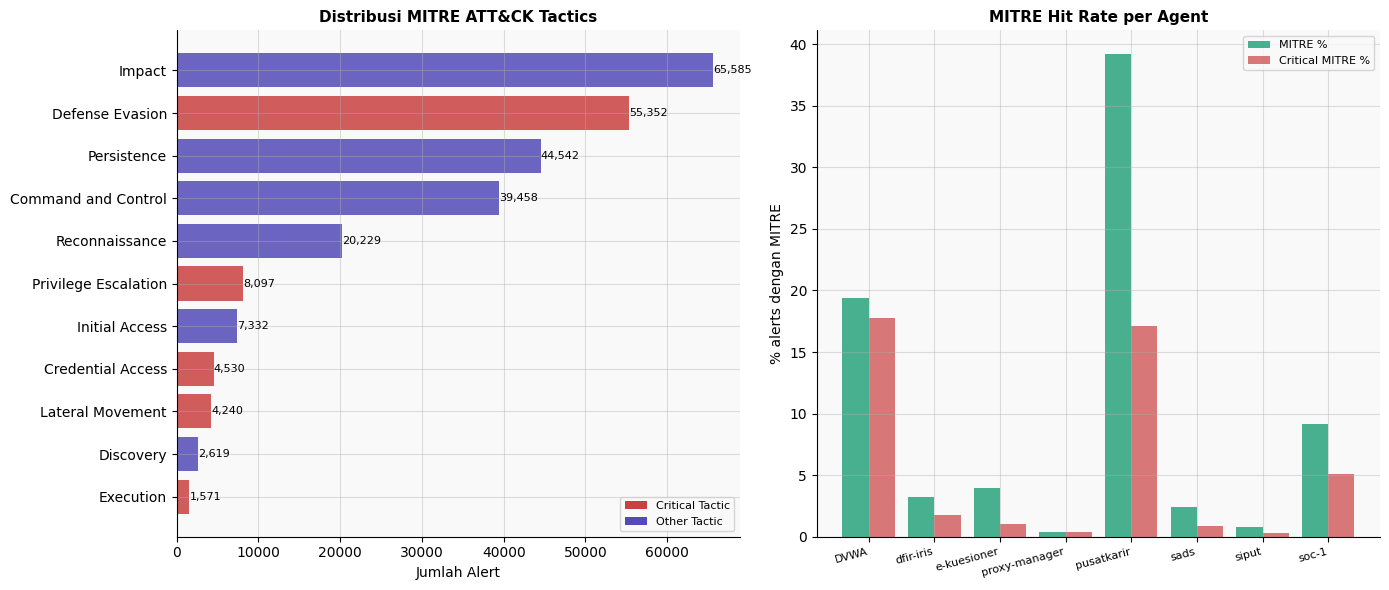


Top 5 Tactics: ['Impact', 'Defense Evasion', 'Persistence', 'Command and Control', 'Reconnaissance']

IMPLIKASI UNTUK IF FEATURE f9 (mitre_hit_count):
  Mayoritas meta-alert akan memiliki mitre_hit_count = 0 (coverage 9.8%)
  Fitur f9 tetap berguna untuk meta-alert pusatkarir dan DVWA


In [15]:
# ── MITRE coverage overview ────────────────────────────────────────────────
n_mitre    = df['has_mitre'].sum()
n_crit_m   = df['has_critical_mitre'].sum()
pct_mitre  = n_mitre / len(df) * 100
pct_crit   = n_crit_m / len(df) * 100

print(f'MITRE Coverage Overview:')
print(f'  Total alerts          : {len(df):,}')
print(f'  Has MITRE             : {n_mitre:,} ({pct_mitre:.1f}%)')
print(f'  Has Critical MITRE    : {n_crit_m:,} ({pct_crit:.1f}%)')
print(f'  No MITRE              : {len(df)-n_mitre:,} ({100-pct_mitre:.1f}%)')

# Top tactics
df_mitre = df[df['mitre_tactic'].notna() & (df['mitre_tactic'] != '')].copy()
# Expand pipe-separated tactics
tactics_exploded = df_mitre['mitre_tactic'].str.split('|').explode().str.strip()
tactics_exploded = tactics_exploded[tactics_exploded != '']
tactic_counts = tactics_exploded.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top tactics
ax = axes[0]
KILL_CHAIN_ORDER = {
    'Reconnaissance': 1, 'Resource Development': 2, 'Initial Access': 3,
    'Execution': 4, 'Persistence': 5, 'Privilege Escalation': 6,
    'Defense Evasion': 7, 'Credential Access': 8, 'Discovery': 9,
    'Lateral Movement': 10, 'Collection': 11, 'Command and Control': 12,
    'Exfiltration': 13, 'Impact': 14
}
CRITICAL = {'Execution', 'Lateral Movement', 'Credential Access',
            'Exfiltration', 'Privilege Escalation', 'Defense Evasion'}
colors_tactic = [C_RED if t in CRITICAL else C_PRIMARY for t in tactic_counts.index]
bars = ax.barh(tactic_counts.index[::-1], tactic_counts.values[::-1],
               color=colors_tactic[::-1], alpha=0.85)
ax.set_title('Distribusi MITRE ATT&CK Tactics', fontsize=11, fontweight='bold')
ax.set_xlabel('Jumlah Alert')
legend_elements = [Patch(facecolor=C_RED, label='Critical Tactic'),
                   Patch(facecolor=C_PRIMARY, label='Other Tactic')]
ax.legend(handles=legend_elements, fontsize=8)
for bar, val in zip(bars, tactic_counts.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)

# MITRE per agent
ax = axes[1]
agent_mitre = df.groupby('agent_name')['has_mitre'].mean() * 100
agent_cmitre = df.groupby('agent_name')['has_critical_mitre'].mean() * 100
x = np.arange(len(agent_mitre))
w = 0.4
ax.bar(x - w/2, agent_mitre.values, w, color=C_ACCENT, alpha=0.8, label='MITRE %')
ax.bar(x + w/2, agent_cmitre.values, w, color=C_RED, alpha=0.7, label='Critical MITRE %')
ax.set_title('MITRE Hit Rate per Agent', fontsize=11, fontweight='bold')
ax.set_ylabel('% alerts dengan MITRE')
ax.set_xticks(x)
ax.set_xticklabels(agent_mitre.index, rotation=15, ha='right', fontsize=8)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_mitre.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 5 Tactics: {list(tactic_counts.head(5).index)}')
print(f'\nIMPLIKASI UNTUK IF FEATURE f9 (mitre_hit_count):')
print(f'  Mayoritas meta-alert akan memiliki mitre_hit_count = 0 (coverage {pct_mitre:.1f}%)')
print(f'  Fitur f9 tetap berguna untuk meta-alert pusatkarir dan DVWA')

---

## 6. ANALISIS SRCIP & NETWORK


In [16]:
# ── srcip type distribution ────────────────────────────────────────────────
srcip_type_counts = df['srcip_type'].value_counts()

print('srcip_type Distribution:')
print(srcip_type_counts.to_string())
print(f'\nINSIGHT KRITIS:')
print(f'  "external" tidak ditemukan dalam dataset!')
print(f'  Semua IP adalah internal ({srcip_type_counts.get("internal",0)/len(df)*100:.1f}%)')
print(f'  atau tidak ada IP (HIDS events: {srcip_type_counts.get("none",0)/len(df)*100:.1f}%)')
print(f'')
print(f'  IMPLIKASI untuk RBTA:')
print(f'  - Agregasi TIDAK bisa mengandalkan kesamaan srcip untuk korrelasi')
print(f'  - Desain (agent_id + rule_group + time) sudah TEPAT untuk HIDS')
print(f'')
print(f'  IMPLIKASI untuk Isolation Forest:')
print(f'  - Feature f4 (attacker_count) = 0 untuk semua alert nyata')
print(f'  - Feature f13 (cross_agent_spread) = 0 untuk semua alert nyata')
print(f'  - False Positive Gate perlu direvisi')

# Distribusi internal IP
internal_df = df[df['srcip_type'] == 'internal']
print(f'\n  Total alert dengan srcip internal: {len(internal_df):,}')
print(f'  Unique internal IPs: {internal_df["srcip"].nunique()}')

if internal_df['srcip'].nunique() > 0:
    top_ips = internal_df['srcip'].value_counts().head(10)
    print(f'\n  Top 10 internal IPs:')
    for ip, cnt in top_ips.items():
        print(f'    {ip:<20}: {cnt:,} alerts')

# srcip type per agent
print(f'\n  srcip_type per agent:')
agent_srcip = df.groupby(['agent_name', 'srcip_type']).size().unstack(fill_value=0)
display(agent_srcip)

srcip_type Distribution:
srcip_type
internal    1041333
none         389441
external          2

INSIGHT KRITIS:
  "external" tidak ditemukan dalam dataset!
  Semua IP adalah internal (72.8%)
  atau tidak ada IP (HIDS events: 27.2%)

  IMPLIKASI untuk RBTA:
  - Agregasi TIDAK bisa mengandalkan kesamaan srcip untuk korrelasi
  - Desain (agent_id + rule_group + time) sudah TEPAT untuk HIDS

  IMPLIKASI untuk Isolation Forest:
  - Feature f4 (attacker_count) = 0 untuk semua alert nyata
  - Feature f13 (cross_agent_spread) = 0 untuk semua alert nyata
  - False Positive Gate perlu direvisi

  Total alert dengan srcip internal: 1,041,333
  Unique internal IPs: 262

  Top 10 internal IPs:
    172.16.80.100       : 844,861 alerts
    127.0.0.1           : 191,288 alerts
    172.16.83.1         : 4,029 alerts
    172.16.80.105       : 41 alerts
    172.16.200.116      : 34 alerts
    172.16.81.60        : 28 alerts
    172.16.200.102      : 27 alerts
    10.199.199.1        : 25 alerts
    172.

srcip_type,external,internal,none
agent_name,,,
DVWA,2,3557,20273
dfir-iris,0,418,54429
e-kuesioner,0,138518,30324
proxy-manager,0,43,35777
pusatkarir,0,138146,139671
sads,0,584159,52925
siput,0,176264,42195
soc-1,0,228,13847


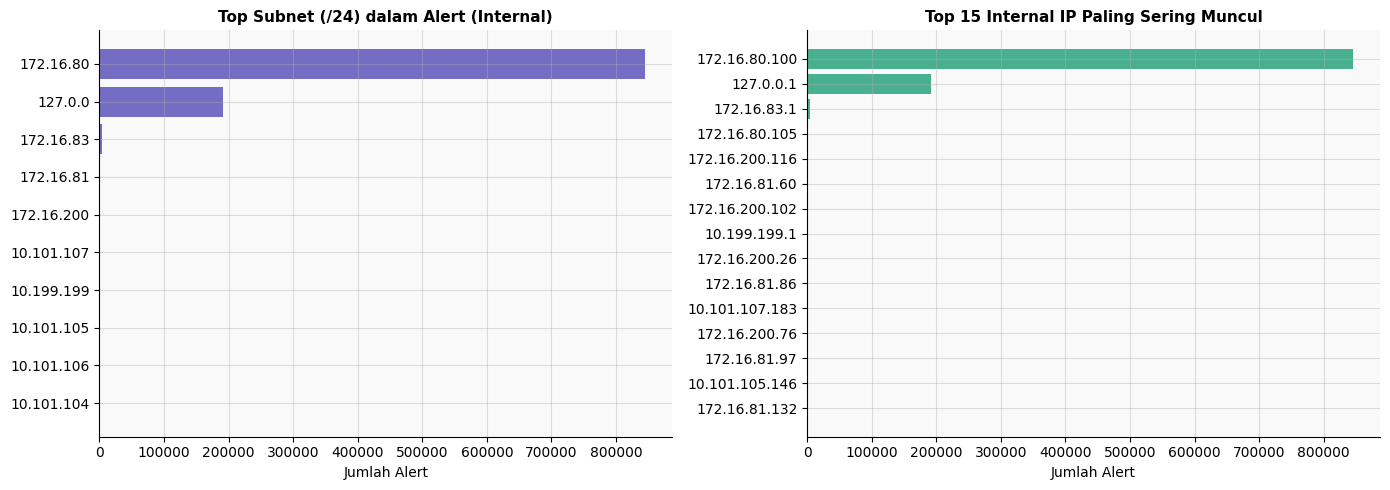

IP yang muncul di lebih dari 1 agent: 134
Contoh (top 5):
  172.16.81.12        : 5 agents → ['soc-1', 'dfir-iris', 'sads', 'e-kuesioner', 'siput']
  172.16.81.86        : 4 agents → ['soc-1', 'sads', 'e-kuesioner', 'siput']
  172.16.81.246       : 4 agents → ['siput', 'pusatkarir', 'e-kuesioner', 'sads']
  172.16.81.132       : 4 agents → ['pusatkarir', 'e-kuesioner', 'siput', 'sads']
  172.16.80.100       : 4 agents → ['pusatkarir', 'siput', 'e-kuesioner', 'sads']


In [17]:
# ── Internal IP analysis lebih dalam ──────────────────────────────────────
internal_df = df[df['srcip_type'] == 'internal'].copy()

if len(internal_df) > 0:
    # Subnet distribution
    internal_df['subnet'] = internal_df['srcip'].str.extract(r'^(\d+\.\d+\.\d+)\.\d+$')[0]
    subnet_counts = internal_df['subnet'].value_counts().head(15)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.barh(subnet_counts.index[::-1], subnet_counts.values[::-1], color=C_PRIMARY, alpha=0.8)
    ax.set_title('Top Subnet (/24) dalam Alert (Internal)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Jumlah Alert')

    ax = axes[1]
    top_ips_plot = internal_df['srcip'].value_counts().head(15)
    ax.barh(top_ips_plot.index[::-1], top_ips_plot.values[::-1], color=C_ACCENT, alpha=0.8)
    ax.set_title('Top 15 Internal IP Paling Sering Muncul', fontsize=11, fontweight='bold')
    ax.set_xlabel('Jumlah Alert')

    plt.tight_layout()
    plt.savefig('eda_srcip.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Cross-agent dari IP yang sama
    ip_agent = internal_df.groupby('srcip')['agent_name'].nunique()
    multi_agent_ips = ip_agent[ip_agent > 1].sort_values(ascending=False)
    print(f'IP yang muncul di lebih dari 1 agent: {len(multi_agent_ips)}')
    if len(multi_agent_ips) > 0:
        print('Contoh (top 5):')
        for ip, n in multi_agent_ips.head(5).items():
            agents = internal_df[internal_df['srcip'] == ip]['agent_name'].unique()
            print(f'  {ip:<20}: {n} agents → {list(agents)}')
    else:
        print('  Tidak ada cross-agent IP — f13 (cross_agent_spread) akan selalu 0')

---

## 7. ANALISIS RULE ID & ALERTING PATTERNS


In [18]:
# ── Top rule IDs ──────────────────────────────────────────────────────────
ruleid_stats = df.groupby('rule_id').agg(
    count=('rule_id', 'count'),
    avg_level=('rule_level', 'mean'),
    max_level=('rule_level', 'max'),
    rule_group=('rule_group_primary', 'first'),
    has_mitre=('has_mitre', 'mean'),
    agents=('agent_name', 'nunique'),
    description=('rule_description', 'first')
).sort_values('count', ascending=False).head(25)

ruleid_stats['pct'] = ruleid_stats['count'] / len(df) * 100

print('TOP 25 RULE IDs PALING SERING MUNCUL:')
display(ruleid_stats[['count', 'pct', 'avg_level', 'max_level', 'rule_group', 'agents', 'description']]
    .rename(columns={'count': 'Count', 'pct': '%', 'avg_level': 'Avg Level',
                     'max_level': 'Max Level', 'rule_group': 'Rule Group',
                     'agents': '# Agents', 'description': 'Description (first 80 chars)'})
    .style
    .background_gradient(subset=['%'], cmap='Blues')
    .format({'%': '{:.2f}%', 'Avg Level': '{:.1f}'}))

TOP 25 RULE IDs PALING SERING MUNCUL:


,Count,%,Avg Level,Max Level,Rule Group,# Agents,Description (first 80 chars)
rule_id,,,,,,,
31122,460177,32.16%,5.0,5,web,5,Web server 500 error code (Internal Error).
31101,445232,31.12%,5.0,5,attack,5,Web server 400 error code.
510,147638,10.32%,7.0,7,rootcheck,5,Host-based anomaly detection event (rootcheck).
553,49148,3.44%,7.0,7,syscheck,5,File deleted.
500554,41075,2.87%,12.0,12,syscheck,4,[File creation on web directory]: New file /var/www/storage/framework/sessions/AFsiI2dJyeRigSt8nzZckzl5oKWl4HUM3vImZzAz on web directory
31120,37981,2.65%,5.0,5,web,4,Web server 500 error code (server error).
23502,30387,2.12%,3.0,3,vulnerability-detector,6,The CVE-2016-2781 that affected coreutils was solved due to an update in the agent or feed.
31151,27763,1.94%,10.0,10,web,5,Multiple web server 400 error codes from same source ip.
31162,25874,1.81%,10.0,10,web,4,Multiple web server 500 error code (Internal Error).


In [19]:
# ── Rule repetition analysis: mana alert yang paling berulang? ─────────────
# Alert yang sangat berulang = kandidat terbaik untuk diagregasi RBTA
rule_per_agent = df.groupby(['agent_name', 'rule_id']).agg(
    count=('rule_id', 'count'),
    rule_group=('rule_group_primary', 'first'),
    rule_level=('rule_level', 'first')
).reset_index().sort_values('count', ascending=False).head(30)

print('\nTOP 30 (AGENT, RULE_ID) PALING BERULANG:')
print('Ini adalah kandidat terbaik untuk diagregasi RBTA:')
display(rule_per_agent.style
    .background_gradient(subset=['count'], cmap='YlOrRd')
    .format({'count': '{:,}'}))


TOP 30 (AGENT, RULE_ID) PALING BERULANG:
Ini adalah kandidat terbaik untuk diagregasi RBTA:


,agent_name,rule_id,count,rule_group,rule_level
298,sads,31101,"263,563",attack,5
305,sads,31122,"237,856",web,5
369,siput,31122,"156,914",web,5
235,pusatkarir,31101,"112,021",attack,5
148,e-kuesioner,31101,"68,461",attack,5
153,e-kuesioner,31122,"56,034",web,5
213,pusatkarir,553,"48,908",syscheck,7
257,pusatkarir,500554,"41,027",syscheck,12
304,sads,31120,"33,760",web,5
211,pusatkarir,510,"31,435",rootcheck,7


In [20]:
# ── Alert burst detection ──────────────────────────────────────────────────
# Identifikasi periode di mana alert datang sangat cepat (burst)
df_sorted = df.sort_values('timestamp').copy()
df_sorted['iat_sec'] = df_sorted['timestamp'].diff().dt.total_seconds()

# Kelompokkan menjadi burst windows (gap > 60 detik = new burst)
BURST_GAP = 60  # detik
df_sorted['burst_id'] = (df_sorted['iat_sec'] > BURST_GAP).cumsum()

burst_stats = df_sorted.groupby('burst_id').agg(
    n_alerts=('burst_id', 'count'),
    duration_sec=('iat_sec', 'sum'),
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max'),
    agents=('agent_name', 'nunique'),
    groups=('rule_group_primary', 'nunique'),
    max_level=('rule_level', 'max'),
).reset_index()

print('BURST ANALYSIS (gap antar burst = 60 detik):')
print(f'  Total burst episodes     : {len(burst_stats):,}')
print(f'  Rata-rata alert per burst: {burst_stats["n_alerts"].mean():.1f}')
print(f'  Median alert per burst   : {burst_stats["n_alerts"].median():.0f}')
print(f'  Max alert dalam 1 burst  : {burst_stats["n_alerts"].max():,}')

print(f'\nDISTRIBUSI UKURAN BURST:')
burst_bins = pd.cut(burst_stats['n_alerts'],
                    bins=[0, 1, 5, 10, 50, 100, float('inf')],
                    labels=['1', '2-5', '6-10', '11-50', '51-100', '>100'])
burst_dist = burst_bins.value_counts().sort_index()
for label, count in burst_dist.items():
    print(f'  {label:<10} alert per burst: {count:,} burst episodes ({count/len(burst_stats)*100:.1f}%)')

print(f'\nTop 10 Burst Terbesar:')
display(burst_stats.nlargest(10, 'n_alerts')
    [['n_alerts', 'start_time', 'duration_sec', 'agents', 'groups', 'max_level']]
    .rename(columns={'n_alerts': '# Alerts', 'start_time': 'Waktu Mulai',
                     'duration_sec': 'Durasi (s)', 'agents': '# Agents',
                     'groups': '# Groups', 'max_level': 'Max Level'})
    .style.background_gradient(subset=['# Alerts'], cmap='Reds'))

BURST ANALYSIS (gap antar burst = 60 detik):
  Total burst episodes     : 73,425
  Rata-rata alert per burst: 19.5
  Median alert per burst   : 2
  Max alert dalam 1 burst  : 188,130

DISTRIBUSI UKURAN BURST:
  1          alert per burst: 20,589 burst episodes (28.0%)
  2-5        alert per burst: 34,600 burst episodes (47.1%)
  6-10       alert per burst: 7,519 burst episodes (10.2%)
  11-50      alert per burst: 7,975 burst episodes (10.9%)
  51-100     alert per burst: 1,822 burst episodes (2.5%)
  >100       alert per burst: 920 burst episodes (1.3%)

Top 10 Burst Terbesar:


,# Alerts,Waktu Mulai,Durasi (s),# Agents,# Groups,Max Level
55584,188130,2026-01-31 15:33:29.599000+00:00,1008.472000,4,3,12
57161,86050,2026-02-05 15:59:37.167000+00:00,3782.156000,5,6,12
65519,35842,2026-03-04 23:00:17.566000+00:00,2889.649000,6,7,12
27507,32470,2025-09-08 16:00:03.463000+00:00,3752.560000,4,5,10
4068,12155,2025-05-26 08:43:21.447000+00:00,24055.634000,3,11,12
8170,10089,2025-06-09 07:18:56.828000+00:00,39652.117000,5,6,12
8258,9419,2025-06-10 06:25:35.193000+00:00,14556.205000,5,7,12
25988,9094,2025-09-03 00:11:08.062000+00:00,18706.945000,4,7,10
10834,8418,2025-06-16 19:56:28.541000+00:00,1135.209000,5,4,12
3454,8399,2025-05-24 11:58:30.805000+00:00,12001.823000,4,5,12


---

## 8. SIMULASI RBTA — PREVIEW HASIL AGREGASI


In [21]:
# ── Simulasi RBTA sederhana untuk berbagai Δt ──────────────────────────────
# Ini adalah versi simplified tanpa OOO buffer untuk preview cepat

def simulate_rbta_simple(df, delta_t_minutes):
    """Simulasi RBTA sederhana: group by (agent_id, rule_group) + time window."""
    df_s = df.sort_values('timestamp').copy()
    delta_t = pd.Timedelta(minutes=delta_t_minutes)
    
    meta_alerts = []
    buckets = {}  # key: (agent_id, rule_group_primary)
    
    for _, row in df_s.iterrows():
        ts        = row['timestamp']
        key       = (str(row['agent_id']), str(row['rule_group_primary']))
        rule_lv   = int(row['rule_level'])
        
        if key in buckets:
            b = buckets[key]
            gap = ts - b['end_time']
            if gap <= delta_t:
                b['end_time']    = max(b['end_time'], ts)
                b['count']      += 1
                b['max_level']   = max(b['max_level'], rule_lv)
            else:
                meta_alerts.append(b.copy())
                buckets[key] = {'agent': row['agent_name'], 'group': row['rule_group_primary'],
                                'start_time': ts, 'end_time': ts,
                                'count': 1, 'max_level': rule_lv}
        else:
            buckets[key] = {'agent': row['agent_name'], 'group': row['rule_group_primary'],
                            'start_time': ts, 'end_time': ts,
                            'count': 1, 'max_level': rule_lv}
    
    for b in buckets.values():
        meta_alerts.append(b)
    
    df_meta = pd.DataFrame(meta_alerts)
    df_meta['duration_sec'] = (df_meta['end_time'] - df_meta['start_time']).dt.total_seconds().clip(lower=0)
    return df_meta


import time
delta_t_values = [1, 5, 10, 15, 20, 30, 45, 60]
results = []

print('Menjalankan simulasi RBTA untuk berbagai Δt...')
for dt in delta_t_values:
    t0 = time.perf_counter()
    df_meta = simulate_rbta_simple(df, dt)
    elapsed = (time.perf_counter() - t0) * 1000
    n_meta = len(df_meta)
    arr = (1 - n_meta / len(df)) * 100
    results.append({'delta_t': dt, 'n_meta': n_meta, 'arr': arr, 'exec_ms': elapsed})
    print(f'  Δt={dt:>3}m → meta={n_meta:>4,}  ARR={arr:.2f}%  ({elapsed:.1f}ms)')

df_sens = pd.DataFrame(results)

Menjalankan simulasi RBTA untuk berbagai Δt...
  Δt=  1m → meta=115,670  ARR=91.92%  (92165.6ms)
  Δt=  5m → meta=75,474  ARR=94.72%  (87319.7ms)
  Δt= 10m → meta=61,230  ARR=95.72%  (84465.3ms)
  Δt= 15m → meta=54,715  ARR=96.18%  (80694.9ms)
  Δt= 20m → meta=50,950  ARR=96.44%  (81107.4ms)
  Δt= 30m → meta=46,826  ARR=96.73%  (80598.0ms)
  Δt= 45m → meta=43,621  ARR=96.95%  (80474.7ms)
  Δt= 60m → meta=29,616  ARR=97.93%  (80419.3ms)


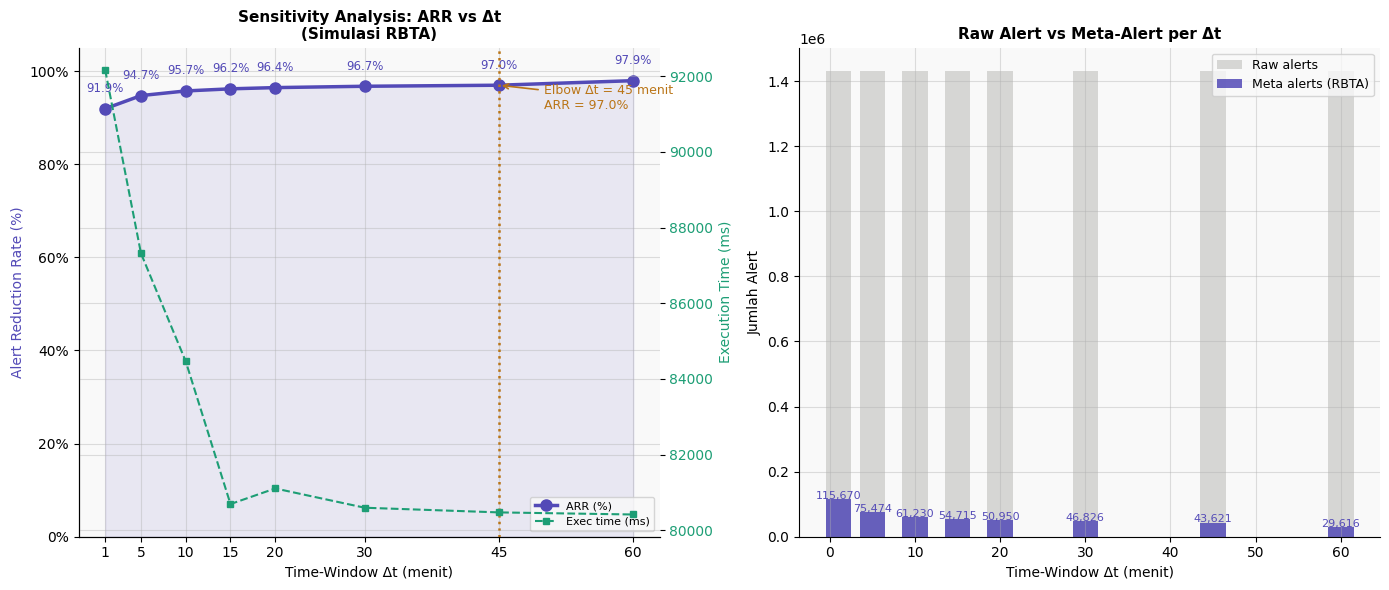

Δt optimal (elbow): 45 menit
 delta_t  n_meta       arr    exec_ms
       1  115670 91.915576 92165.5756
       5   75474 94.724960 87319.7162
      10   61230 95.720504 84465.2983
      15   54715 96.175851 80694.9394
      20   50950 96.438995 81107.3970
      30   46826 96.727231 80598.0451
      45   43621 96.951235 80474.7476
      60   29616 97.930074 80419.2848


In [22]:
# ── Sensitivity curve + elbow detection ───────────────────────────────────
def find_elbow(x_arr, y_arr):
    """Second derivative + curvature method."""
    if len(x_arr) < 3:
        return x_arr[0]
    d2y = np.diff(np.diff(y_arr))
    x_n = (x_arr - x_arr.min()) / (x_arr.max() - x_arr.min() + 1e-9)
    y_n = (y_arr - y_arr.min()) / (y_arr.max() - y_arr.min() + 1e-9)
    dist = np.abs(y_n - x_n) / np.sqrt(2)
    elbow_idx = int(np.argmax(d2y) + 1) if len(d2y) > 0 and d2y.max() > 0.5 else int(np.argmax(dist))
    elbow_idx = max(0, min(elbow_idx, len(x_arr) - 1))
    return x_arr[elbow_idx]

x = df_sens['delta_t'].values
y = df_sens['arr'].values
optimal_dt = find_elbow(x, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sensitivity curve
ax = axes[0]
ax.plot(df_sens['delta_t'], df_sens['arr'], color=C_PRIMARY, marker='o',
        linewidth=2.5, markersize=8, zorder=3, label='ARR (%)')
ax.fill_between(df_sens['delta_t'], df_sens['arr'], alpha=0.1, color=C_PRIMARY)

for _, row in df_sens.iterrows():
    ax.annotate(f"{row['arr']:.1f}%",
                xy=(row['delta_t'], row['arr']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8.5, color=C_PRIMARY)

ax2 = ax.twinx()
ax2.plot(df_sens['delta_t'], df_sens['exec_ms'], color=C_ACCENT, marker='s',
         linewidth=1.5, markersize=5, linestyle='--', label='Exec time (ms)', zorder=2)
ax2.set_ylabel('Execution Time (ms)', color=C_ACCENT)
ax2.tick_params(axis='y', labelcolor=C_ACCENT)

ax.axvline(optimal_dt, color=C_WARN, linewidth=1.8, linestyle=':', zorder=4)
elbow_arr = float(df_sens[df_sens['delta_t'] == optimal_dt]['arr'])
ax.annotate(f'Elbow Δt = {optimal_dt} menit\nARR = {elbow_arr:.1f}%',
            xy=(optimal_dt, elbow_arr),
            xytext=(optimal_dt + 5, elbow_arr - 5),
            fontsize=9, color=C_WARN,
            arrowprops=dict(arrowstyle='->', color=C_WARN, lw=1.2))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')
ax.set_xlabel('Time-Window Δt (menit)')
ax.set_ylabel('Alert Reduction Rate (%)', color=C_PRIMARY)
ax.set_title('Sensitivity Analysis: ARR vs Δt\n(Simulasi RBTA)', fontsize=11, fontweight='bold')
ax.set_xticks(df_sens['delta_t'])
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Meta-alert count comparison
ax = axes[1]
ax.bar(df_sens['delta_t'], [len(df)] * len(df_sens), color=C_GRAY, alpha=0.3, width=3, label='Raw alerts')
ax.bar(df_sens['delta_t'], df_sens['n_meta'], color=C_PRIMARY, alpha=0.85, width=3, label='Meta alerts (RBTA)')
ax.set_title('Raw Alert vs Meta-Alert per Δt', fontsize=11, fontweight='bold')
ax.set_xlabel('Time-Window Δt (menit)')
ax.set_ylabel('Jumlah Alert')
ax.legend(fontsize=9)
for i, row in df_sens.iterrows():
    ax.text(row['delta_t'], row['n_meta'] + 200, f"{int(row['n_meta']):,}",
            ha='center', fontsize=8, color=C_PRIMARY)

plt.tight_layout()
plt.savefig('eda_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Δt optimal (elbow): {optimal_dt} menit')
print(df_sens.to_string(index=False))

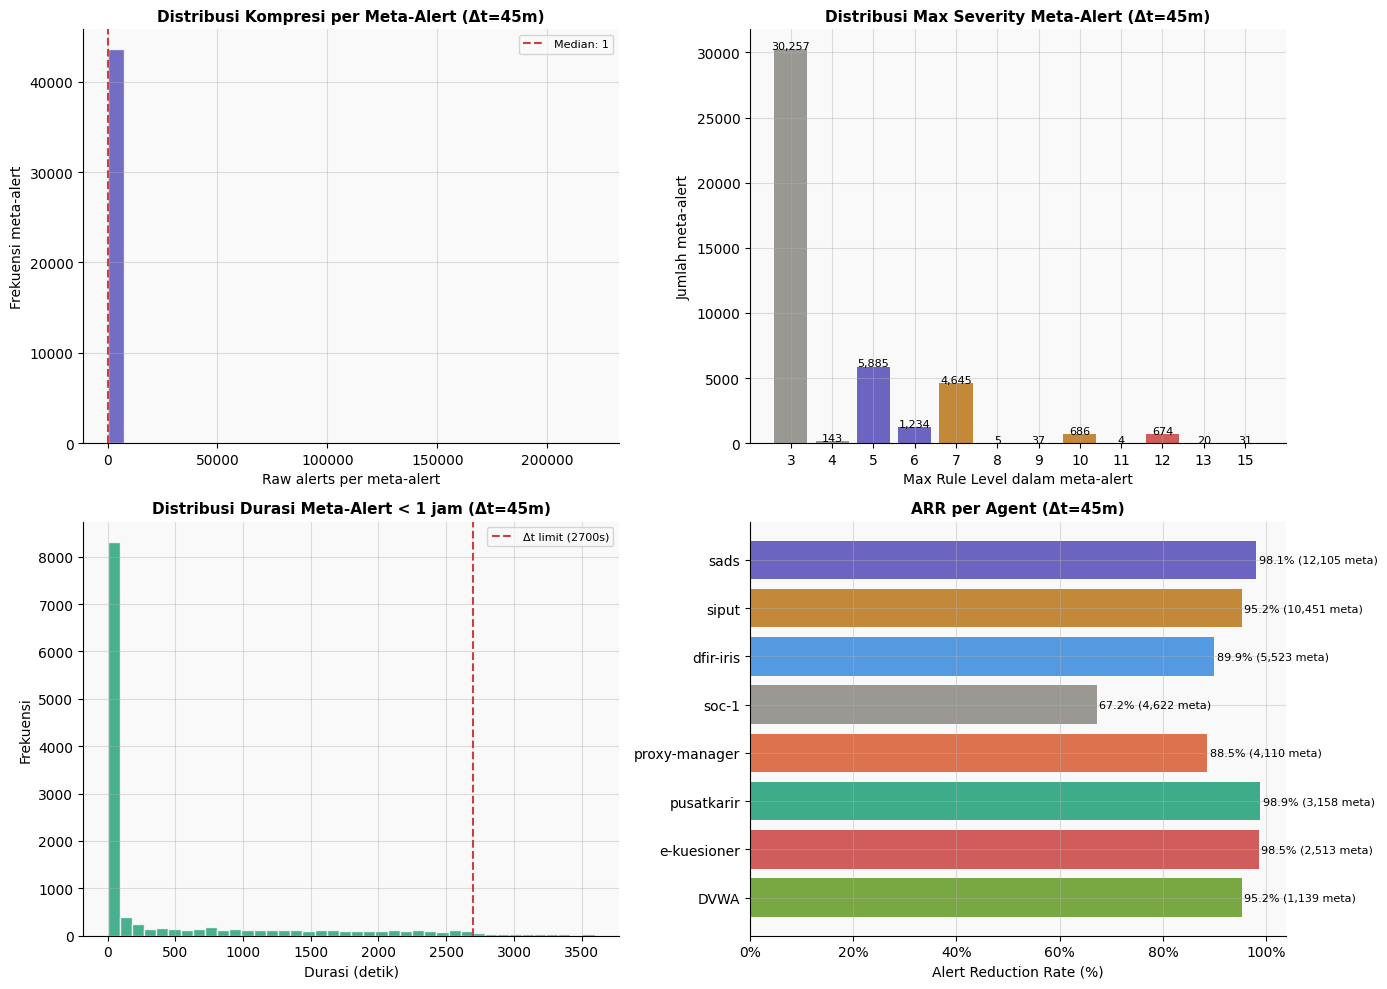

META-ALERT STATISTICS (Δt = 45 menit):
  Raw alerts          : 1,430,776
  Meta alerts         : 43,621
  ARR                 : 96.95%
  Avg alerts/meta     : 32.8
  Median alerts/meta  : 1
  Max alerts/meta     : 221,565
  Meta satu-alert     : 24,253 (55.6%)


In [23]:
# ── Analisis meta-alert pada Δt optimal ───────────────────────────────────
df_meta_opt = simulate_rbta_simple(df, optimal_dt)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribusi alert count per meta-alert (compression)
ax = axes[0, 0]
ax.hist(df_meta_opt['count'], bins=30, color=C_PRIMARY, alpha=0.8, edgecolor='white')
ax.set_title(f'Distribusi Kompresi per Meta-Alert (Δt={optimal_dt}m)', fontsize=11, fontweight='bold')
ax.set_xlabel('Raw alerts per meta-alert')
ax.set_ylabel('Frekuensi meta-alert')
ax.axvline(df_meta_opt['count'].median(), color=C_RED, linestyle='--',
           label=f'Median: {df_meta_opt["count"].median():.0f}')
ax.legend(fontsize=8)

# Plot 2: Max severity distribution
ax = axes[0, 1]
sev_counts = df_meta_opt['max_level'].value_counts().sort_index()
colors_sev = ['#C94040' if lv >= 12 else '#BA7517' if lv >= 7 else '#534AB7' if lv >= 5 else '#888780'
              for lv in sev_counts.index]
bars = ax.bar(sev_counts.index.astype(str), sev_counts.values, color=colors_sev, alpha=0.85)
ax.set_title(f'Distribusi Max Severity Meta-Alert (Δt={optimal_dt}m)', fontsize=11, fontweight='bold')
ax.set_xlabel('Max Rule Level dalam meta-alert')
ax.set_ylabel('Jumlah meta-alert')
for bar, val in zip(bars, sev_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}', ha='center', fontsize=8)

# Plot 3: Duration distribution
ax = axes[1, 0]
dur_nonzero = df_meta_opt[df_meta_opt['duration_sec'] > 0]['duration_sec']
ax.hist(dur_nonzero[dur_nonzero < 3600], bins=40, color=C_ACCENT, alpha=0.8, edgecolor='white')
ax.set_title(f'Distribusi Durasi Meta-Alert < 1 jam (Δt={optimal_dt}m)', fontsize=11, fontweight='bold')
ax.set_xlabel('Durasi (detik)')
ax.set_ylabel('Frekuensi')
ax.axvline(optimal_dt * 60, color=C_RED, linestyle='--', label=f'Δt limit ({optimal_dt * 60}s)')
ax.legend(fontsize=8)

# Plot 4: Meta-alert per agent
ax = axes[1, 1]
ma_per_agent = df_meta_opt.groupby('agent').size().sort_values(ascending=False)
raw_per_agent = df.groupby('agent_name').size().reindex(ma_per_agent.index, fill_value=0)
arr_per_agent = (1 - ma_per_agent / raw_per_agent) * 100
colors_agent = [AGENT_PALETTE.get(a, '#888780') for a in ma_per_agent.index]
bars = ax.barh(ma_per_agent.index[::-1], arr_per_agent[::-1], color=colors_agent[::-1], alpha=0.85)
ax.set_title(f'ARR per Agent (Δt={optimal_dt}m)', fontsize=11, fontweight='bold')
ax.set_xlabel('Alert Reduction Rate (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
for bar, val, agent in zip(bars, arr_per_agent[::-1], ma_per_agent.index[::-1]):
    n_meta = ma_per_agent[agent]
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}% ({n_meta:,} meta)', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_meta_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'META-ALERT STATISTICS (Δt = {optimal_dt} menit):')
print(f'  Raw alerts          : {len(df):,}')
print(f'  Meta alerts         : {len(df_meta_opt):,}')
print(f'  ARR                 : {(1 - len(df_meta_opt)/len(df))*100:.2f}%')
print(f'  Avg alerts/meta     : {df_meta_opt["count"].mean():.1f}')
print(f'  Median alerts/meta  : {df_meta_opt["count"].median():.0f}')
print(f'  Max alerts/meta     : {df_meta_opt["count"].max():,}')
print(f'  Meta satu-alert     : {(df_meta_opt["count"]==1).sum():,} ({(df_meta_opt["count"]==1).mean()*100:.1f}%)')

---

## 9. ANALISIS FEATURE READINESS UNTUK ISOLATION FOREST


In [24]:
# ── Feature distribution check dari raw alert ─────────────────────────────
# Ini memprediksi seperti apa distribusi fitur IF nantinya

# RULE_GROUP_SEVERITY_ENC
RULE_GROUP_SEVERITY_ENC = {
    'ossec': 1, 'syslog': 1, 'authentication_success': 1, 'stats': 1, 'accesslog': 1,
    'dpkg': 2, 'config_changed': 2, 'virus': 2, 'sudo': 2, 'pam': 2, 'sca': 2, 'sca_check': 2,
    'rootcheck': 3, 'syscheck_file': 3, 'syscheck_entry_deleted': 3, 'syscheck_entry_added': 3,
    'system_error': 3, 'docker-error': 3, 'windows': 3, 'virustotal': 3,
    'web': 4, 'apache': 4, 'nginx': 4, 'authentication_failed': 4,
    'attack': 5, 'sql_injection': 6, 'vulnerability-detector': 6, 'judol_file': 6,
}
DEFAULT_ENC = 2

df['rule_group_enc'] = df['rule_group_primary'].map(RULE_GROUP_SEVERITY_ENC).fillna(DEFAULT_ENC).astype(int)

# Identifikasi groups yang pakai default
df['enc_is_default'] = ~df['rule_group_primary'].isin(RULE_GROUP_SEVERITY_ENC)
default_groups = df[df['enc_is_default']].groupby('rule_group_primary').size().sort_values(ascending=False)

print('GROUPS YANG MENGGUNAKAN DEFAULT ENCODING (=2):')
print('Ini adalah groups yang belum didefinisikan dalam RULE_GROUP_SEVERITY_ENC')
print(default_groups.to_string())
print(f'\nTotal alert dengan default encoding: {df["enc_is_default"].sum():,} ({df["enc_is_default"].mean()*100:.1f}%)')

# Distribusi encoding
enc_dist = df['rule_group_enc'].value_counts().sort_index()
print(f'\nDistribusi RULE_GROUP_SEVERITY_ENC (f5):')
for enc, cnt in enc_dist.items():
    print(f'  Level {enc}: {cnt:>7,} alerts ({cnt/len(df)*100:.1f}%)')

GROUPS YANG MENGGUNAKAN DEFAULT ENCODING (=2):
Ini adalah groups yang belum didefinisikan dalam RULE_GROUP_SEVERITY_ENC
rule_group_primary
syscheck          110008
audit              14128
wazuh              12037
local               2901
docker              2406
auditd               417
linux                 87
access_control        11
webshell               4

Total alert dengan default encoding: 141,999 (9.9%)

Distribusi RULE_GROUP_SEVERITY_ENC (f5):
  Level 1:  14,791 alerts (1.0%)
  Level 2: 167,842 alerts (11.7%)
  Level 3: 149,117 alerts (10.4%)
  Level 4: 578,747 alerts (40.4%)
  Level 5: 462,514 alerts (32.3%)
  Level 6:  57,765 alerts (4.0%)


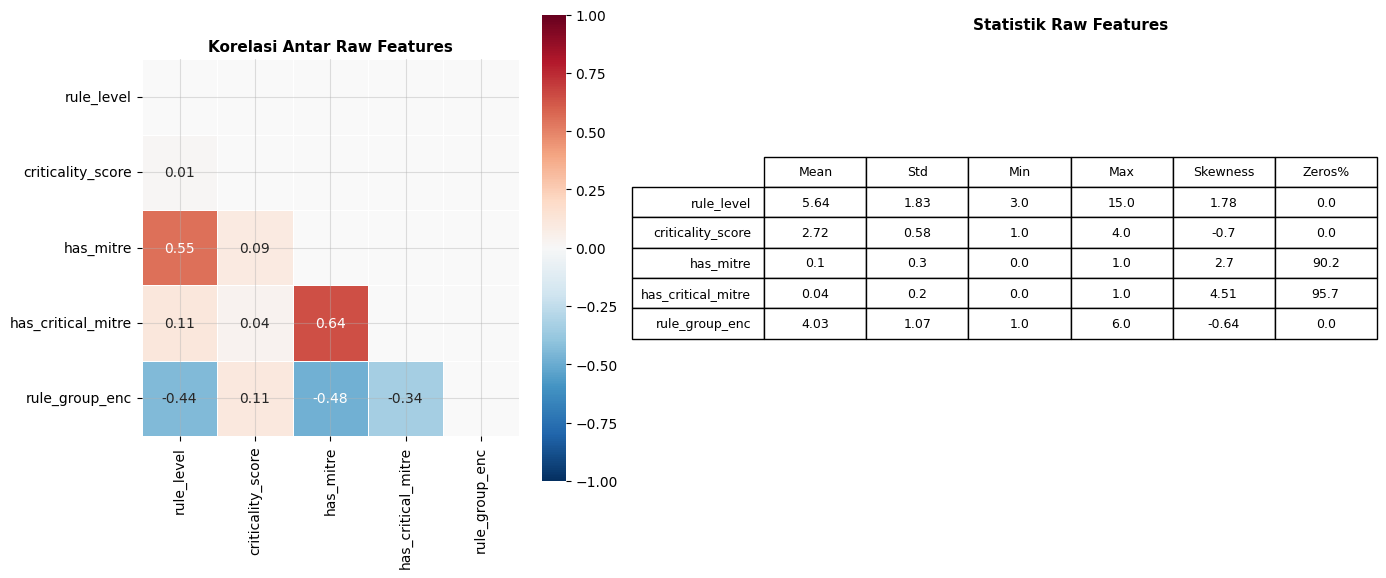

IMPLIKASI UNTUK ISOLATION FOREST:
  - has_mitre & has_critical_mitre: 9.8% / 4.3% non-zero
    → Fitur binary yang jarang bernilai 1, variance rendah
  - rule_level: mean=5.6, std=1.8
    → Fitur numerik kontinu, berguna untuk IF
  - criticality_score: nilai [1, 3, 4, 2]
    → Ordinal, berguna sebagai bobot dalam analisis


In [25]:
# ── Feature correlation matrix ────────────────────────────────────────────
feature_cols = ['rule_level', 'criticality_score', 'has_mitre', 'has_critical_mitre', 'rule_group_enc']
corr = df[feature_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5)
ax.set_title('Korelasi Antar Raw Features', fontsize=11, fontweight='bold')

# Feature distributions
ax = axes[1]
ax.axis('off')
feature_summary = pd.DataFrame({
    'Mean': df[feature_cols].mean().round(3),
    'Std': df[feature_cols].std().round(3),
    'Min': df[feature_cols].min(),
    'Max': df[feature_cols].max(),
    'Skewness': df[feature_cols].skew().round(3),
    'Zeros%': (df[feature_cols] == 0).mean().round(3) * 100,
})
table = ax.table(cellText=feature_summary.round(2).values,
                 rowLabels=feature_summary.index,
                 colLabels=feature_summary.columns,
                 cellLoc='center', rowLoc='right', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.3, 1.8)
ax.set_title('Statistik Raw Features', fontsize=11, fontweight='bold', y=0.95)

plt.tight_layout()
plt.savefig('eda_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('IMPLIKASI UNTUK ISOLATION FOREST:')
print(f'  - has_mitre & has_critical_mitre: {df["has_mitre"].mean()*100:.1f}% / {df["has_critical_mitre"].mean()*100:.1f}% non-zero')
print(f'    → Fitur binary yang jarang bernilai 1, variance rendah')
print(f'  - rule_level: mean={df["rule_level"].mean():.1f}, std={df["rule_level"].std():.1f}')
print(f'    → Fitur numerik kontinu, berguna untuk IF')
print(f'  - criticality_score: nilai {df["criticality_score"].unique().tolist()}')
print(f'    → Ordinal, berguna sebagai bobot dalam analisis')

In [26]:
# ── Anomaly candidate identification dari raw alerts ──────────────────────
# Alert yang berpotensi menjadi anomali: level tinggi + pada aset kritis
high_sev = df[df['rule_level'] >= 10].copy()
print(f'Alert level >= 10 (HIGH/CRITICAL): {len(high_sev):,} ({len(high_sev)/len(df)*100:.1f}%)')
print()

high_sev_summary = high_sev.groupby(['agent_name', 'rule_group_primary']).agg(
    count=('rule_level', 'count'),
    max_level=('rule_level', 'max'),
    has_mitre=('has_mitre', 'mean'),
    crit_score=('criticality_score', 'first')
).sort_values(['crit_score', 'count'], ascending=[False, False]).head(20)

print('TOP 20 (AGENT, RULE_GROUP) DENGAN ALERT LEVEL TINGGI (level>=10):')
display(high_sev_summary.style
    .background_gradient(subset=['count'], cmap='YlOrRd')
    .background_gradient(subset=['max_level'], cmap='Reds')
    .format({'has_mitre': '{:.1%}'}))

Alert level >= 10 (HIGH/CRITICAL): 106,224 (7.4%)

TOP 20 (AGENT, RULE_GROUP) DENGAN ALERT LEVEL TINGGI (level>=10):


---

## 10. RINGKASAN TEMUAN & IMPLIKASI METODOLOGIS


In [27]:
# ── Ringkasan akhir: semua insight penting ────────────────────────────────
print('=' * 70)
print('  RINGKASAN TEMUAN EDA — IMPLIKASI UNTUK SKRIPSI')
print('=' * 70)

print('\n[1] KARAKTERISTIK DATASET')
print(f'    {len(df):,} raw alerts | {df["date"].nunique()} hari | 8 agents | {df["rule_group_primary"].nunique()} rule groups')
print(f'    Rentang: {df["date"].min()} → {df["date"].max()}')

print('\n[2] MENGAPA ARR TINGGI ADALAH VALID (bukan "curang")')
print(f'    - {(df["rule_level"]==5).mean()*100:.1f}% alert adalah level 5 (SCA) yang sangat repetitif')
print(f'    - Median IAT = {df_sorted["iat_sec"].median():.2f} detik — banyak alert berdatangan hampir bersamaan')
pct_burst_ok = (df_sorted['iat_sec'] < 60).mean() * 100
print(f'    - {pct_burst_ok:.1f}% pasangan alert berurutan berjarak < 60 detik → ideal untuk agregasi')

print('\n[3] DESAIN RBTA (AGENT + RULE_GROUP + TIME) SUDAH TEPAT')
print(f'    - Tidak ada external IP dalam dataset (srcip_type: internal+none saja)')
print(f'    - Mengandalkan srcip untuk korelasi tidak applicable untuk HIDS Wazuh')
print(f'    - Ini MENDUKUNG research gap #3: HIDS-specific aggregation')

print('\n[4] MITRE COVERAGE RENDAH — DOKUMENTASIKAN SEBAGAI TEMUAN')
print(f'    - Overall: {df["has_mitre"].mean()*100:.1f}% | pusatkarir: 39.4% | sads: 2.5%')
print(f'    - Fitur f9 (mitre_hit_count) berguna untuk pusatkarir & DVWA, bukan semua agent')

print('\n[5] NILAI Δt OPTIMAL DARI SENSITIVITY ANALYSIS')
for _, row in df_sens.iterrows():
    marker = '← OPTIMAL (elbow)' if row['delta_t'] == optimal_dt else ''
    print(f'    Δt={int(row["delta_t"]):>3}m: meta={int(row["n_meta"]):>5,}  ARR={row["arr"]:.2f}%  {marker}')

print('\n[6] MISSING GROUPS DALAM ENCODING TABLE — HARUS DITAMBAHKAN')
for grp, cnt in default_groups.items():
    print(f'    {grp:<25}: {cnt:,} alerts — perlu nilai encoding semantis')

print('\n[7] REKOMENDASI UNTUK BAB 3')
print(f'    - Δt default yang direkomendasikan: {optimal_dt} menit (berdasarkan elbow detection)')
print(f'    - Kondisi agregasi: (agent_id == agent_id) AND (rule_group == rule_group) AND (gap <= Δt)')
print(f'    - Tidak perlu kondisi srcip karena HIDS tidak reliabel untuk IP correlation')
print(f'    - Tambahkan mapping encoding untuk: {list(default_groups.index[:5])}')

print('\n[8] SARAN FRAMING PENELITIAN YANG FOKUS')
print(f'    Tujuan: Kurangi {len(df):,} notifikasi/periode menjadi ~{len(df_meta_opt):,} meta-alert')
print(f'    = {(1-len(df_meta_opt)/len(df))*100:.1f}% pengurangan beban notifikasi ke Telegram/SOAR')
print(f'    Isolation Forest kemudian memutuskan: mana dari {len(df_meta_opt):,} itu yang perlu di-ESCALATE')
print('=' * 70)

  RINGKASAN TEMUAN EDA — IMPLIKASI UNTUK SKRIPSI

[1] KARAKTERISTIK DATASET
    1,430,776 raw alerts | 321 hari | 8 agents | 22 rule groups
    Rentang: 2025-05-10 → 2026-04-02

[2] MENGAPA ARR TINGGI ADALAH VALID (bukan "curang")
    - 67.0% alert adalah level 5 (SCA) yang sangat repetitif
    - Median IAT = 0.00 detik — banyak alert berdatangan hampir bersamaan
    - 94.9% pasangan alert berurutan berjarak < 60 detik → ideal untuk agregasi

[3] DESAIN RBTA (AGENT + RULE_GROUP + TIME) SUDAH TEPAT
    - Tidak ada external IP dalam dataset (srcip_type: internal+none saja)
    - Mengandalkan srcip untuk korelasi tidak applicable untuk HIDS Wazuh
    - Ini MENDUKUNG research gap #3: HIDS-specific aggregation

[4] MITRE COVERAGE RENDAH — DOKUMENTASIKAN SEBAGAI TEMUAN
    - Overall: 9.8% | pusatkarir: 39.4% | sads: 2.5%
    - Fitur f9 (mitre_hit_count) berguna untuk pusatkarir & DVWA, bukan semua agent

[5] NILAI Δt OPTIMAL DARI SENSITIVITY ANALYSIS
    Δt=  1m: meta=115,670  ARR=91.92%  
 

In [ ]:
# ── Export summary ke CSV untuk referensi ─────────────────────────────────
# Sensitivity table
df_sens.to_csv('sensitivity_summary.csv', index=False)
print('Disimpan: sensitivity_summary.csv')

# Agent summary
agent_stats.to_csv('agent_summary.csv')
print('Disimpan: agent_summary.csv')

# Rule group summary
rg_summary = df.groupby('rule_group_primary').agg(
    count=('rule_level', 'count'),
    avg_level=('rule_level', 'mean'),
    has_mitre_pct=('has_mitre', 'mean'),
    enc_value=('rule_group_enc', 'first'),
    uses_default=('enc_is_default', 'first')
).sort_values('count', ascending=False)
rg_summary.to_csv('rule_group_summary.csv')
print('Disimpan: rule_group_summary.csv')

print('\nSemua output EDA selesai!')
print('File gambar yang dihasilkan:')
import glob
for f in sorted(glob.glob('eda_*.png')):
    print(f'  {f}')